Using Colab cache for faster access to the 'mit-place-pulse' dataset.
[setup] device=cuda | IMAGE_DIR=/kaggle/input/mit-place-pulse/gsv/final_photo_dataset
[data] train_pairs=358,304 | val_pairs=4,400
[data] computing train + val win-rate scores...
       train images scored: 78,335
       val   images scored: 703
[baselines] color-hist features for 5,000 train images...


[baselines] HOG features for 5,000 train images...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[siamese] loading siamese_best.pt...
          best epoch=3 | val_pair_acc=0.6755

[eval] Random


       pair_acc=0.5068  [0.4916, 0.5218]  |  Spearman ρ=0.027

[eval] Mean predictor


       pair_acc=0.5030  [0.4893, 0.5177]  |  Spearman ρ=nan

[eval] Color hist + Ridge


/tmp/ipykernel_996/286048377.py:197: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(pred, ref)


       pair_acc=0.5795  [0.5659, 0.5950]  |  Spearman ρ=0.227

[eval] HOG + LinearSVR (StreetScore replica)


       pair_acc=0.5625  [0.5489, 0.5777]  |  Spearman ρ=0.160

[eval] Siamese (ours)


       pair_acc=0.6750  [0.6607, 0.6889]  |  Spearman ρ=0.460

[results] saved /content/drive/MyDrive/place_pulse_safety/results/comparison_table.csv
                               method  pair_acc    ci_lo    ci_hi  n_pairs  spearman_rho  spearman_n     note
                               Random  0.506818 0.491585 0.521818   4400.0      0.027052       703.0      NaN
                       Mean predictor  0.502955 0.489318 0.517727   4400.0           NaN       703.0      NaN
                   Color hist + Ridge  0.579545 0.565903 0.595000   4400.0      0.227136       703.0      NaN
HOG + LinearSVR (StreetScore replica)  0.562500 0.548864 0.577733   4400.0      0.160167       703.0      NaN
                       Siamese (ours)  0.675000 0.660676 0.688864   4400.0      0.460007       703.0      NaN
   Dubey et al. 2016 (ECCV, reported)  0.730000      NaN      NaN      NaN           NaN         NaN reported
[fig] saved /content/drive/MyDrive/place_pulse_safety/figures/training_curves.pn

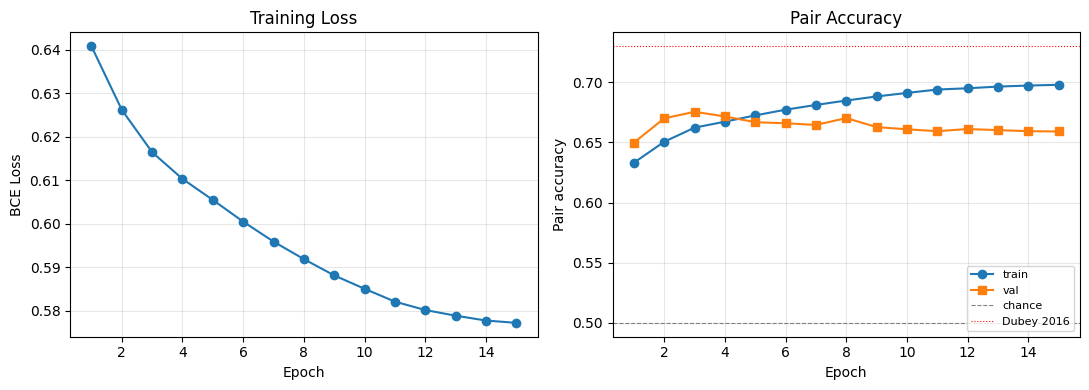

[city] no city metadata found — skipping per-city figure.
       Discuss as a limitation in the report's fairness section.
[fig] saved /content/drive/MyDrive/place_pulse_safety/figures/gradcam_4panel.png


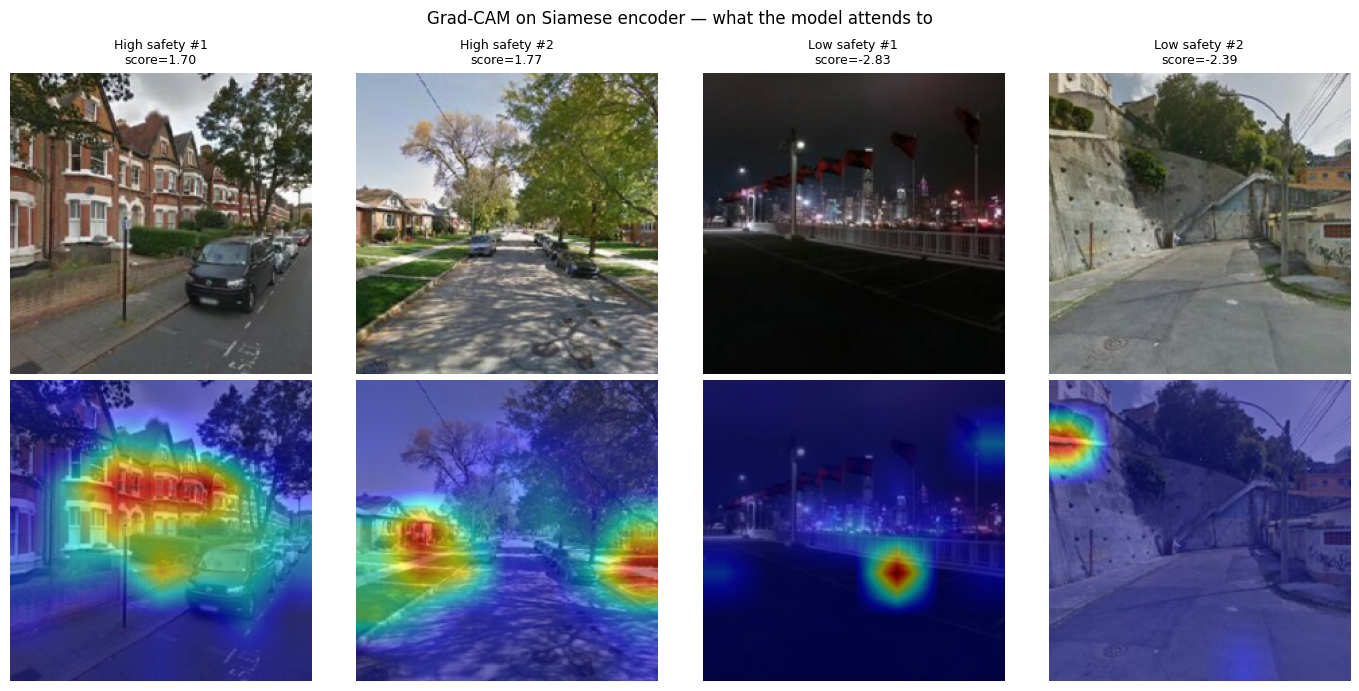


[done] all artifacts in /content/drive/MyDrive/place_pulse_safety/
       results/comparison_table.csv    -> main table for report
       figures/training_curves.png     -> Figure 3
       figures/per_city_errors.png     -> fairness figure
       figures/gradcam_4panel.png      -> interpretability figure
       results/post_summary.json       -> all numbers in one place


In [ ]:
"""
Post-training pipeline — paste as ONE cell right after the training cell.

Runs ~15-20 minutes on Colab and produces every artifact your report needs,
saved to Drive under /content/drive/MyDrive/place_pulse_safety/:

  results/comparison_table.csv     # the master Results table
  results/per_city_errors.csv      # the fairness data
  figures/training_curves.png      # Fig 3 (train/val curves vs Dubey 73%)
  figures/per_city_errors.png      # Fig: fairness bar chart by city
  figures/gradcam_4panel.png       # Fig: Grad-CAM interpretability
  results/post_summary.json        # all final numbers in one place

The five methods evaluated, all through the same eval function:
  Random | Mean predictor | Color hist + Ridge | HOG + LinearSVR | Siamese (ours)
Plus a reference row for Dubey et al. 2016 (reported, 0.730 pair acc).

Wall-clock split: HOG features ~6 min, scoring val images ~3 min, the rest fast.
"""
import os, json, time, random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.amp import autocast
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from skimage.feature import hog
from skimage.color import rgb2gray
from scipy.stats import spearmanr
from tqdm.auto import tqdm
import kagglehub

# ============================================================
# 0. Paths (must match your training cell)
# ============================================================
PROJECT_DIR    = "/content/drive/MyDrive/place_pulse_safety"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
DATA_CACHE_DIR = f"{PROJECT_DIR}/data"
LOG_DIR        = f"{PROJECT_DIR}/logs"
RESULTS_DIR    = f"{PROJECT_DIR}/results"
FIGURES_DIR    = f"{PROJECT_DIR}/figures"
for d in (RESULTS_DIR, FIGURES_DIR):
    os.makedirs(d, exist_ok=True)

DATA_DIR  = kagglehub.dataset_download("shubham6147/mit-place-pulse")
IMAGE_DIR = Path(DATA_DIR) / "gsv/final_photo_dataset"
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[setup] device={device} | IMAGE_DIR={IMAGE_DIR}")

# ============================================================
# 1. Load splits and compute win-rate reference scores
# ============================================================
train_df = pd.read_csv(f"{DATA_CACHE_DIR}/train_pairs.csv")
val_df   = pd.read_csv(f"{DATA_CACHE_DIR}/val_pairs.csv")
print(f"[data] train_pairs={len(train_df):,} | val_pairs={len(val_df):,}")

def win_rate_scores(votes_df, min_votes=3):
    wins, losses = {}, {}
    for _, r in votes_df.iterrows():
        L, R, c = str(r["left"]), str(r["right"]), str(r["choice"]).lower()
        if c == "left":
            wins[L]   = wins.get(L, 0) + 1
            losses[R] = losses.get(R, 0) + 1
        elif c == "right":
            wins[R]   = wins.get(R, 0) + 1
            losses[L] = losses.get(L, 0) + 1
    out = {}
    for img in set(wins) | set(losses):
        n = wins.get(img, 0) + losses.get(img, 0)
        if n >= min_votes:
            out[img] = wins.get(img, 0) / n
    return out

print("[data] computing train + val win-rate scores...")
train_scores_dict = win_rate_scores(train_df)
val_scores_dict   = win_rate_scores(val_df)
print(f"       train images scored: {len(train_scores_dict):,}")
print(f"       val   images scored: {len(val_scores_dict):,}")

# ============================================================
# 2. Classical feature extractors
# ============================================================
def load_rgb(path, size=96):
    return np.asarray(Image.open(path).convert("RGB").resize((size, size)),
                      dtype=np.float32) / 255.0

def color_hist_features(path, bins=8):
    img = load_rgb(path)
    feats = []
    for c in range(3):
        h, _ = np.histogram(img[..., c], bins=bins, range=(0, 1))
        feats.append(h.astype(np.float32) / max(h.sum(), 1))
    return np.concatenate(feats)

def hog_features(path):
    gray = rgb2gray(load_rgb(path))
    return hog(gray, orientations=8, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), feature_vector=True).astype(np.float32)

# ============================================================
# 3. Fit classical baselines on 5,000 train images
# ============================================================
HOG_TRAIN_SAMPLE = 5000
random.seed(42)
train_pool = sorted(train_scores_dict.keys())
random.shuffle(train_pool)
train_sample = train_pool[:HOG_TRAIN_SAMPLE]
train_y = np.array([train_scores_dict[i] for i in train_sample])
train_mean = float(train_y.mean())

print(f"[baselines] color-hist features for {len(train_sample):,} train images...")
X_color = np.stack([color_hist_features(IMAGE_DIR / f"{i}.jpg")
                    for i in tqdm(train_sample, desc="color", leave=False)])
ridge_model = Ridge(alpha=1.0).fit(X_color, train_y)

print(f"[baselines] HOG features for {len(train_sample):,} train images...")
X_hog = np.stack([hog_features(IMAGE_DIR / f"{i}.jpg")
                  for i in tqdm(train_sample, desc="hog", leave=False)])
svr_model = LinearSVR(C=1.0, max_iter=5000, random_state=42).fit(X_hog, train_y)

def fn_random(_):       return float(np.random.rand())
def fn_mean(_):         return train_mean
def fn_ridge(path):     return float(ridge_model.predict(color_hist_features(path)[None, :])[0])
def fn_svr(path):       return float(svr_model.predict(hog_features(path)[None, :])[0])

# ============================================================
# 4. Load best Siamese and build its score function
# ============================================================
class SiameseResNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    def forward_once(self, x):
        x = self.backbone(x); x = x.view(x.size(0), -1)
        return self.head(x)

print("[siamese] loading siamese_best.pt...")
ckpt = torch.load(f"{CHECKPOINT_DIR}/siamese_best.pt", map_location=device)
print(f"          best epoch={ckpt['epoch']} | val_pair_acc={ckpt['val_pair_acc']:.4f}")
siamese = SiameseResNet().to(device)
siamese.load_state_dict(ckpt["model_state_dict"])
siamese.eval()

EVAL_TFM = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def fn_siamese(path):
    img = Image.open(path).convert("RGB")
    x = EVAL_TFM(img).unsqueeze(0).to(device)
    with autocast("cuda"):
        return float(siamese.forward_once(x).item())

# ============================================================
# 5. Unified evaluation: pair acc + bootstrap CI + Spearman ρ
# ============================================================
def evaluate(name, score_fn):
    print(f"\n[eval] {name}")
    unique_ids = pd.unique(pd.concat([val_df["left"].astype(str),
                                       val_df["right"].astype(str)]))
    score_map = {}
    for img_id in tqdm(unique_ids, desc=f"  scoring", leave=False):
        score_map[img_id] = float(score_fn(IMAGE_DIR / f"{img_id}.jpg"))

    sL = np.array([score_map[str(i)] for i in val_df["left"]])
    sR = np.array([score_map[str(i)] for i in val_df["right"]])
    y  = (val_df["choice"].str.lower() == "left").astype(int).values
    correct = ((sL > sR).astype(int) == y).astype(float)
    acc = correct.mean()

    rng = np.random.default_rng(0)
    boots = [correct[rng.integers(0, len(correct), len(correct))].mean()
             for _ in range(1000)]
    lo, hi = float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))

    out = {"method": name, "pair_acc": float(acc),
           "ci_lo": lo, "ci_hi": hi, "n_pairs": len(val_df)}

    common = [i for i in unique_ids if i in val_scores_dict]
    if len(common) >= 20:
        pred = np.array([score_map[i]        for i in common])
        ref  = np.array([val_scores_dict[i]  for i in common])
        rho, _ = spearmanr(pred, ref)
        out["spearman_rho"] = float(rho)
        out["spearman_n"]   = len(common)

    rho_str = f"{out.get('spearman_rho', float('nan')):.3f}"
    print(f"       pair_acc={acc:.4f}  [{lo:.4f}, {hi:.4f}]  |  Spearman ρ={rho_str}")
    return out, score_map

results = []
all_score_maps = {}
for nm, fn in [("Random",                                fn_random),
               ("Mean predictor",                        fn_mean),
               ("Color hist + Ridge",                    fn_ridge),
               ("HOG + LinearSVR (StreetScore replica)", fn_svr),
               ("Siamese (ours)",                        fn_siamese)]:
    r, sm = evaluate(nm, fn)
    results.append(r)
    all_score_maps[nm] = sm

results.append({"method": "Dubey et al. 2016 (ECCV, reported)",
                "pair_acc": 0.730, "ci_lo": None, "ci_hi": None,
                "spearman_rho": None, "n_pairs": None, "note": "reported"})

results_df = pd.DataFrame(results)
results_df.to_csv(f"{RESULTS_DIR}/comparison_table.csv", index=False)
print(f"\n[results] saved {RESULTS_DIR}/comparison_table.csv")
print(results_df.to_string(index=False))

# ============================================================
# 6. Training curves figure (Figure 3 in your report)
# ============================================================
log = pd.read_csv(f"{LOG_DIR}/training_log.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log["epoch"], log["train_loss"], marker="o")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Training Loss"); axes[0].grid(alpha=0.3)
axes[1].plot(log["epoch"], log["train_acc"],    marker="o", label="train")
axes[1].plot(log["epoch"], log["val_pair_acc"], marker="s", label="val")
axes[1].axhline(0.50, color="grey", linestyle="--", linewidth=0.8, label="chance")
axes[1].axhline(0.73, color="red",  linestyle=":",  linewidth=0.8, label="Dubey 2016")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Pair accuracy")
axes[1].set_title("Pair Accuracy")
axes[1].legend(loc="lower right", fontsize=8); axes[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/training_curves.png", dpi=200, bbox_inches="tight")
print(f"[fig] saved {FIGURES_DIR}/training_curves.png")
plt.show()

# ============================================================
# 7. Per-city fairness figure
# ============================================================
places_csv = None
for name in ("places.csv", "places_metadata.csv", "metadata.csv",
             "cities.csv", "places.tsv"):
    p = Path(DATA_DIR) / name
    if p.exists():
        places_csv = p; break

image_to_city = {}
if places_csv:
    sep = "\t" if str(places_csv).endswith(".tsv") else ","
    pdf = pd.read_csv(places_csv, sep=sep)
    id_col   = next((c for c in ("image_id", "place_id", "id") if c in pdf.columns), None)
    city_col = next((c for c in ("city", "place_name", "location") if c in pdf.columns), None)
    if id_col and city_col:
        for _, row in pdf.iterrows():
            image_to_city[str(row[id_col]).strip().lower()] = str(row[city_col]).strip()
        print(f"[city] loaded {len(image_to_city):,} image->city entries from {places_csv.name}")

if image_to_city:
    siamese_scores = all_score_maps["Siamese (ours)"]
    vx = val_df.copy()
    vx["left_city"]  = vx["left"].astype(str).map(image_to_city)
    vx["right_city"] = vx["right"].astype(str).map(image_to_city)
    same = vx.dropna(subset=["left_city", "right_city"])
    same = same[same["left_city"] == same["right_city"]]
    rows = []
    for city, g in same.groupby("left_city"):
        if len(g) < 20: continue
        sL = np.array([siamese_scores[str(i)] for i in g["left"]])
        sR = np.array([siamese_scores[str(i)] for i in g["right"]])
        y  = (g["choice"].str.lower() == "left").astype(int).values
        acc = float(((sL > sR).astype(int) == y).mean())
        rows.append({"city": city, "n_pairs": len(g), "pair_acc": acc})
    per_city = pd.DataFrame(rows).sort_values("pair_acc", ascending=False).reset_index(drop=True)
    per_city.to_csv(f"{RESULTS_DIR}/per_city_errors.csv", index=False)

    overall = results_df.loc[results_df["method"] == "Siamese (ours)", "pair_acc"].values[0]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(per_city)), per_city["pair_acc"], color="#4878a6")
    ax.set_xticks(range(len(per_city)))
    ax.set_xticklabels(per_city["city"], rotation=60, ha="right", fontsize=8)
    ax.axhline(0.50, color="grey", linestyle="--", linewidth=0.8, label="chance")
    ax.axhline(overall, color="red", linestyle="-.", linewidth=1.0,
               label=f"overall ({overall:.3f})")
    for i, (a, n) in enumerate(zip(per_city["pair_acc"], per_city["n_pairs"])):
        ax.text(i, a + 0.005, f"N={n}", ha="center", va="bottom", fontsize=6)
    ax.set_ylabel("Pair accuracy"); ax.set_title("Per-city pair accuracy (Siamese)")
    ax.legend(loc="lower left", fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/per_city_errors.png", dpi=200, bbox_inches="tight")
    print(f"[fig] saved {FIGURES_DIR}/per_city_errors.png")
    plt.show()
else:
    print("[city] no city metadata found — skipping per-city figure.")
    print("       Discuss as a limitation in the report's fairness section.")

# ============================================================
# 8. Grad-CAM 4-panel (interpretability)
# ============================================================
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    os.system("pip install -q grad-cam")
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

scored = sorted(all_score_maps["Siamese (ours)"].items(), key=lambda kv: kv[1])
demo_low  = [img for img, _ in scored[:2]]
demo_high = [img for img, _ in scored[-2:]]

RAW_TFM = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])
target_layer = siamese.backbone[-2][-1]

class _Wrap(nn.Module):
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m.forward_once(x)

cam = GradCAM(model=_Wrap(siamese).to(device), target_layers=[target_layer])

def panel(image_id, ax_raw, ax_cam, title):
    img = Image.open(IMAGE_DIR / f"{image_id}.jpg").convert("RGB")
    raw = np.asarray(RAW_TFM(img)) / 255.0
    x = EVAL_TFM(img).unsqueeze(0).to(device)
    cam_map = cam(input_tensor=x, targets=None)[0]
    overlay = show_cam_on_image(raw, cam_map, use_rgb=True)
    ax_raw.imshow(raw); ax_raw.axis("off")
    s = all_score_maps["Siamese (ours)"][image_id]
    ax_raw.set_title(f"{title}\nscore={s:.2f}", fontsize=9)
    ax_cam.imshow(overlay); ax_cam.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, img_id in enumerate(demo_high):
    panel(img_id, axes[0, i],   axes[1, i],   f"High safety #{i+1}")
for i, img_id in enumerate(demo_low):
    panel(img_id, axes[0, i+2], axes[1, i+2], f"Low safety #{i+1}")
fig.suptitle("Grad-CAM on Siamese encoder — what the model attends to", fontsize=12)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/gradcam_4panel.png", dpi=200, bbox_inches="tight")
print(f"[fig] saved {FIGURES_DIR}/gradcam_4panel.png")
plt.show()

# ============================================================
# 9. Final summary
# ============================================================
summary = {
    "best_val_pair_acc": float(ckpt["val_pair_acc"]),
    "best_epoch": int(ckpt["epoch"]),
    "comparison_table": results_df.to_dict(orient="records"),
    "n_train_pairs": int(len(train_df)),
    "n_val_pairs":   int(len(val_df)),
    "n_train_images_scored": int(len(train_scores_dict)),
    "n_val_images_scored":   int(len(val_scores_dict)),
}
with open(f"{RESULTS_DIR}/post_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(f"\n[done] all artifacts in {PROJECT_DIR}/")
print(f"       results/comparison_table.csv    -> main table for report")
print(f"       figures/training_curves.png     -> Figure 3")
print(f"       figures/per_city_errors.png     -> fairness figure")
print(f"       figures/gradcam_4panel.png      -> interpretability figure")
print(f"       results/post_summary.json       -> all numbers in one place")

In [ ]:
"""
Place Pulse 2.0 — Siamese ResNet-50 training (Colab + Google Drive, robust).

This is the Colab version with hardened Drive integration:

  - Auto-mounts Drive with retry on failure
  - All artifacts (checkpoints, split CSVs, training log, results) live on
    Drive under /content/drive/MyDrive/place_pulse_safety/
  - Atomic writes (tmp + rename) so a session disconnect mid-save cannot
    corrupt any file
  - Cached train/val splits: re-runs skip the (slow) data filter and just
    re-load from Drive
  - Resume-from-checkpoint: if the last run died at epoch 7, the next run
    starts at epoch 8 with optimizer, scheduler, and AMP scaler restored
  - Best-checkpoint tracking survives a resume

Works the same on Kaggle (paths point to /kaggle/working) or local machines
(paths point to ./project_output). The detect_environment() function below
picks the right one.

Run as a single cell. The only env-specific step is the initial Drive
authorisation prompt that pops up the first time.
"""
from __future__ import annotations
import os
import re
import sys
import glob
import time
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torch.amp import autocast, GradScaler  # unified AMP API (PyTorch >= 2.4)
from PIL import Image
import kagglehub
from tqdm.auto import tqdm


# ============================================================
# 0. CONFIG
# ============================================================
SEED         = 42
BATCH_SIZE   = 128         # bump to 256 on A100-80GB if memory allows
NUM_EPOCHS   = 15
INITIAL_LR   = 1e-4
WEIGHT_DECAY = 1e-4
VAL_FRAC     = 0.10
IMG_SIZE     = 224
NUM_WORKERS  = 4
PROJECT_NAME = "place_pulse_safety"

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True


# ============================================================
# 1. ENV DETECTION + DRIVE MOUNT (with retry)
# ============================================================
def detect_environment_and_setup(project_name: str = PROJECT_NAME):
    """
    Returns (env_name, project_dir). On Colab, mounts Drive and creates the
    project folder under MyDrive. On Kaggle, returns /kaggle/working. Local
    falls back to ./project_output.
    """
    # --- Colab ---
    if "google.colab" in sys.modules:
        from google.colab import drive
        print("[env] Colab detected. Mounting Google Drive...")
        try:
            drive.mount("/content/drive")
        except Exception as e:
            print(f"[env] First mount attempt failed: {e}")
            print("[env] Retrying with force_remount=True...")
            drive.mount("/content/drive", force_remount=True)
        base = f"/content/drive/MyDrive/{project_name}"
        os.makedirs(base, exist_ok=True)
        # Verify write access
        probe = os.path.join(base, ".write_probe")
        try:
            with open(probe, "w") as f:
                f.write("ok")
            os.remove(probe)
        except Exception as e:
            raise RuntimeError(
                f"[env] Drive write probe failed at {base}: {e}. "
                "Check Drive quota or permissions."
            )
        print(f"[env] Drive ready -> {base}")
        return "colab", base

    # --- Kaggle ---
    if os.path.isdir("/kaggle/working"):
        base = "/kaggle/working"
        print(f"[env] Kaggle detected -> {base}")
        return "kaggle", base

    # --- Local ---
    base = os.path.abspath("./project_output")
    os.makedirs(base, exist_ok=True)
    print(f"[env] Local environment -> {base}")
    return "local", base


ENV, PROJECT_DIR = detect_environment_and_setup()
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
DATA_CACHE_DIR = os.path.join(PROJECT_DIR, "data")
LOG_DIR        = os.path.join(PROJECT_DIR, "logs")
RESULTS_DIR    = os.path.join(PROJECT_DIR, "results")
FIGURES_DIR    = os.path.join(PROJECT_DIR, "figures")
for d in (CHECKPOINT_DIR, DATA_CACHE_DIR, LOG_DIR, RESULTS_DIR, FIGURES_DIR):
    os.makedirs(d, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[env] device={device} | torch {torch.__version__}")
print(f"[env] CHECKPOINT_DIR = {CHECKPOINT_DIR}")
print(f"[env] DATA_CACHE_DIR = {DATA_CACHE_DIR}")
print(f"[env] LOG_DIR        = {LOG_DIR}")


# ============================================================
# 2. ATOMIC SAVE / LOAD HELPERS
# ============================================================
def atomic_torch_save(state: dict, path: str):
    """Write to <path>.tmp, then rename. Atomic on POSIX, so a kernel
    crash mid-save cannot leave a half-written checkpoint on Drive."""
    tmp = path + ".tmp"
    torch.save(state, tmp)
    os.replace(tmp, path)


def atomic_csv_save(df: pd.DataFrame, path: str):
    tmp = path + ".tmp"
    df.to_csv(tmp, index=False)
    os.replace(tmp, path)


def safe_torch_load(path: str, map_location=None):
    """Load a checkpoint; if the file is corrupt, fall back to .tmp if it
    exists. Returns None if both fail."""
    try:
        return torch.load(path, map_location=map_location)
    except Exception as e:
        print(f"[load] {path} failed: {e}")
        tmp = path + ".tmp"
        if os.path.exists(tmp):
            try:
                print(f"[load] trying {tmp} as fallback...")
                return torch.load(tmp, map_location=map_location)
            except Exception as e2:
                print(f"[load] tmp also failed: {e2}")
        return None


def find_latest_checkpoint(checkpoint_dir: str):
    """Returns (path, epoch_number) of the highest-numbered checkpoint that
    actually loads, or (None, 0) if none exist."""
    pattern = os.path.join(checkpoint_dir, "siamese_epoch_*.pt")
    files = sorted(glob.glob(pattern),
                   key=lambda p: int(re.findall(r"epoch_(\d+)", p)[0]),
                   reverse=True)
    for f in files:
        if safe_torch_load(f, map_location="cpu") is not None:
            ep = int(re.findall(r"epoch_(\d+)", f)[0])
            return f, ep
    return None, 0


# ============================================================
# 3. DATASET DOWNLOAD (via kagglehub) + IMAGE DIR
# ============================================================
print("\n[1/6] Downloading Place Pulse 2.0 (via kagglehub)...")
DATA_DIR  = kagglehub.dataset_download("shubham6147/mit-place-pulse")
IMAGE_DIR = os.path.join(DATA_DIR, "gsv/final_photo_dataset")
VOTES_CSV = os.path.join(DATA_DIR, "votes_clean.csv")
print(f"  DATA_DIR  = {DATA_DIR}")
print(f"  IMAGE_DIR = {IMAGE_DIR}")
print(f"  VOTES_CSV = {VOTES_CSV}")


# ============================================================
# 4. LOAD AND FILTER VOTES (or load cached splits from Drive)
# ============================================================
TRAIN_CSV = os.path.join(DATA_CACHE_DIR, "train_pairs.csv")
VAL_CSV   = os.path.join(DATA_CACHE_DIR, "val_pairs.csv")

if os.path.exists(TRAIN_CSV) and os.path.exists(VAL_CSV):
    print(f"\n[2/6] Loading cached splits from Drive...")
    train_df = pd.read_csv(TRAIN_CSV)
    val_df   = pd.read_csv(VAL_CSV)
    print(f"  train pairs: {len(train_df):,} | val pairs: {len(val_df):,}")
    print(f"  (delete {DATA_CACHE_DIR} to rebuild from raw votes)")
else:
    print("\n[2/6] Building train/val splits from raw votes (one-time cost)...")
    df = pd.read_csv(VOTES_CSV)
    df = df[(df["study_question"] == "safer") &
            (df["choice"].isin(["left", "right"]))].copy()
    df["left"]  = df["left"].astype(str).str.strip().str.lower()
    df["right"] = df["right"].astype(str).str.strip().str.lower()
    print(f"  {len(df):,} safety votes after attribute+choice filter")

    valid_images = {f.split(".")[0].strip().lower()
                    for f in os.listdir(IMAGE_DIR) if f.endswith(".jpg")}
    print(f"  {len(valid_images):,} images on disk")

    df = df[df["left"].isin(valid_images) &
            df["right"].isin(valid_images)].reset_index(drop=True)
    print(f"  {len(df):,} pairs after image-existence filter")

    unique_imgs = sorted(set(df["left"]).union(set(df["right"])))
    rng = np.random.default_rng(SEED)
    shuffled = unique_imgs.copy()
    rng.shuffle(shuffled)
    n_val = int(len(shuffled) * VAL_FRAC)
    val_image_set = set(shuffled[:n_val])

    both_train = (~df["left"].isin(val_image_set)) & (~df["right"].isin(val_image_set))
    both_val   = df["left"].isin(val_image_set) & df["right"].isin(val_image_set)
    train_df = df[both_train].reset_index(drop=True)
    val_df   = df[both_val].reset_index(drop=True)
    print(f"  train pairs: {len(train_df):,} | val pairs: {len(val_df):,}")

    atomic_csv_save(train_df, TRAIN_CSV)
    atomic_csv_save(val_df,   VAL_CSV)
    print(f"  cached -> {TRAIN_CSV}, {VAL_CSV}")


# ============================================================
# 5. DATASET / DATALOADERS
# ============================================================
class PlacePulseSiameseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_left  = Image.open(os.path.join(self.img_dir, f"{row['left']}.jpg")).convert("RGB")
        img_right = Image.open(os.path.join(self.img_dir, f"{row['right']}.jpg")).convert("RGB")
        if self.transform is not None:
            img_left  = self.transform(img_left)
            img_right = self.transform(img_right)
        target = 1.0 if row["choice"] == "left" else 0.0
        return img_left, img_right, torch.tensor(target, dtype=torch.float32)


MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
train_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
eval_tfm = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = PlacePulseSiameseDataset(train_df, IMAGE_DIR, transform=train_tfm)
val_ds   = PlacePulseSiameseDataset(val_df,   IMAGE_DIR, transform=eval_tfm)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0), drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE * 2, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True,
                          persistent_workers=(NUM_WORKERS > 0))


# ============================================================
# 6. MODEL
# ============================================================
class SiameseResNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward_once(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        return self.head(x)

    def forward(self, left, right):
        s_left  = self.forward_once(left)
        s_right = self.forward_once(right)
        return (s_left - s_right).squeeze(-1)


print("\n[3/6] Building model...")
model = SiameseResNet()
if torch.cuda.device_count() > 1:
    print(f"  Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)
model = model.to(device)


# ============================================================
# 7. OPTIM, LOSS, SCHED, AMP
# ============================================================
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=INITIAL_LR,
                              weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
scaler    = GradScaler("cuda")


def set_backbone_trainable(m, trainable: bool):
    target = m.module.backbone if isinstance(m, nn.DataParallel) else m.backbone
    for p in target.parameters():
        p.requires_grad = trainable


# ============================================================
# 8. RESUME FROM LATEST CHECKPOINT (if any)
# ============================================================
print("\n[4/6] Checking for resumable checkpoint...")
resume_path, resume_epoch = find_latest_checkpoint(CHECKPOINT_DIR)
start_epoch  = 1
best_val_acc = 0.0
history      = []

if resume_path is not None:
    print(f"  Resuming from {resume_path} (epoch {resume_epoch})")
    ckpt = safe_torch_load(resume_path, map_location=device)
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if "scaler_state_dict" in ckpt:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    start_epoch  = resume_epoch + 1
    best_val_acc = float(ckpt.get("best_val_acc", ckpt.get("val_pair_acc", 0.0)))
    # Reload history from log if present
    log_path = os.path.join(LOG_DIR, "training_log.csv")
    if os.path.exists(log_path):
        history = pd.read_csv(log_path).to_dict(orient="records")
        print(f"  Loaded {len(history)} prior epochs from {log_path}")
    if start_epoch > NUM_EPOCHS:
        print(f"  Already trained {resume_epoch}/{NUM_EPOCHS} epochs. Nothing to do.")
        sys.exit(0)
else:
    print("  No checkpoint found, training from scratch.")


# ============================================================
# 9. CHECKPOINT SAVE WITH ATOMIC WRITE
# ============================================================
def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                    train_loss, val_acc, best_val_acc):
    state_dict = (model.module.state_dict() if isinstance(model, nn.DataParallel)
                  else model.state_dict())
    payload = {
        "epoch": epoch,
        "model_state_dict": state_dict,
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "train_loss": train_loss,
        "val_pair_acc": val_acc,
        "best_val_acc": best_val_acc,
    }
    atomic_torch_save(payload, path)


# ============================================================
# 10. VAL EVAL
# ============================================================
@torch.no_grad()
def evaluate_val(model, loader):
    model.eval()
    correct = total = 0
    pbar = tqdm(loader, desc="  val", leave=False, ncols=100)
    for xL, xR, y in pbar:
        xL = xL.to(device, non_blocking=True)
        xR = xR.to(device, non_blocking=True)
        y  = y.to(device,  non_blocking=True)
        with autocast("cuda"):
            logit = model(xL, xR)
        pred = (logit > 0).float()
        correct += (pred == y).sum().item()
        total   += y.numel()
        pbar.set_postfix(val_acc=f"{correct/max(total,1)*100:.2f}%")
    return correct / max(total, 1)


# ============================================================
# 11. TRAINING LOOP — saves to Drive after every epoch
# ============================================================
print(f"\n[5/6] Training from epoch {start_epoch} to {NUM_EPOCHS}...")
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    # Freeze backbone for epoch 1, then unfreeze with LR / 10
    if epoch == 1:
        print(f"Epoch {epoch}: freezing backbone.")
        set_backbone_trainable(model, False)
    elif epoch == 2:
        print(f"Epoch {epoch}: unfreezing backbone, LR -> {INITIAL_LR / 10:.1e}")
        set_backbone_trainable(model, True)
        for g in optimizer.param_groups:
            g["lr"] = INITIAL_LR / 10.0
    elif epoch == start_epoch and start_epoch > 2:
        # Resuming mid-training; make sure backbone is unfrozen
        set_backbone_trainable(model, True)

    model.train()
    running_loss = 0.0
    correct = total = 0
    t0 = time.time()

    pbar = tqdm(train_loader,
                desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [train]",
                leave=False, ncols=100)
    for xL, xR, y in pbar:
        xL = xL.to(device, non_blocking=True)
        xR = xR.to(device, non_blocking=True)
        y  = y.to(device,  non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda"):
            logit = model(xL, xR)
            loss  = criterion(logit, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * y.size(0)
        pred = (logit > 0).float()
        correct += (pred == y).sum().item()
        total   += y.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{correct/total*100:.2f}%")

    scheduler.step()
    train_loss = running_loss / total
    train_acc  = correct / total
    val_acc    = evaluate_val(model, val_loader)
    dt_min     = (time.time() - t0) / 60.0
    print(f"--- Epoch {epoch:02d} | "
          f"train_loss={train_loss:.4f} | "
          f"train_acc={train_acc:.4f} | "
          f"val_pair_acc={val_acc:.4f} | "
          f"{dt_min:.1f} min ---")

    history.append({
        "epoch": epoch, "train_loss": train_loss,
        "train_acc": train_acc, "val_pair_acc": val_acc,
        "minutes": dt_min,
    })

    # Save per-epoch checkpoint and update best
    is_new_best = val_acc > best_val_acc
    if is_new_best:
        best_val_acc = val_acc

    epoch_ckpt = os.path.join(CHECKPOINT_DIR, f"siamese_epoch_{epoch:02d}.pt")
    save_checkpoint(epoch_ckpt, epoch, model, optimizer, scheduler, scaler,
                    train_loss, val_acc, best_val_acc)
    print(f"  saved {epoch_ckpt}")

    if is_new_best:
        best_ckpt = os.path.join(CHECKPOINT_DIR, "siamese_best.pt")
        save_checkpoint(best_ckpt, epoch, model, optimizer, scheduler, scaler,
                        train_loss, val_acc, best_val_acc)
        print(f"  ** new best val_pair_acc={val_acc:.4f} -> {best_ckpt} **")

    # Save training log (atomic) every epoch
    atomic_csv_save(pd.DataFrame(history),
                    os.path.join(LOG_DIR, "training_log.csv"))


# ============================================================
# 12. FINAL SUMMARY
# ============================================================
print(f"\n[6/6] DONE. Best val pair acc: {best_val_acc:.4f}")
print(f"Reference: Dubey et al. 2016 reports 0.73 on the same task.")
print(f"All artifacts saved under: {PROJECT_DIR}")
print("  - checkpoints/  : per-epoch + siamese_best.pt")
print("  - data/         : train_pairs.csv, val_pairs.csv")
print("  - logs/         : training_log.csv")
print("  - results/      : (populate with eval + baselines)")
print("  - figures/      : (populate with Grad-CAM + per-city)")

summary = {
    "best_val_pair_acc": float(best_val_acc),
    "num_epochs_completed": int(history[-1]["epoch"]) if history else 0,
    "num_train_pairs": int(len(train_df)),
    "num_val_pairs": int(len(val_df)),
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "lr": INITIAL_LR,
    "weight_decay": WEIGHT_DECAY,
    "device": str(device),
    "env": ENV,
    "project_dir": PROJECT_DIR,
}
import json
with open(os.path.join(RESULTS_DIR, "siamese_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)
print(f"  wrote {os.path.join(RESULTS_DIR, 'siamese_summary.json')}")

[env] Colab detected. Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[env] Drive ready -> /content/drive/MyDrive/place_pulse_safety
[env] device=cuda | torch 2.10.0+cu128
[env] CHECKPOINT_DIR = /content/drive/MyDrive/place_pulse_safety/checkpoints
[env] DATA_CACHE_DIR = /content/drive/MyDrive/place_pulse_safety/data
[env] LOG_DIR        = /content/drive/MyDrive/place_pulse_safety/logs

[1/6] Downloading Place Pulse 2.0 (via kagglehub)...
Using Colab cache for faster access to the 'mit-place-pulse' dataset.
  DATA_DIR  = /kaggle/input/mit-place-pulse
  IMAGE_DIR = /kaggle/input/mit-place-pulse/gsv/final_photo_dataset
  VOTES_CSV = /kaggle/input/mit-place-pulse/votes_clean.csv

[2/6] Loading cached splits from Drive...
  train pairs: 358,304 | val pairs: 4,400
  (delete /content/drive/MyDrive/place_pulse_safety/data to rebuild from raw votes)

[3/6] Building model...

[4/6] Checking

--- Epoch 01 | train_loss=0.6409 | train_acc=0.6331 | val_pair_acc=0.6498 | 16.7 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_01.pt
  ** new best val_pair_acc=0.6498 -> /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_best.pt **
Epoch 2: unfreezing backbone, LR -> 1.0e-05


--- Epoch 02 | train_loss=0.6262 | train_acc=0.6505 | val_pair_acc=0.6700 | 16.3 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_02.pt
  ** new best val_pair_acc=0.6700 -> /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_best.pt **


--- Epoch 03 | train_loss=0.6165 | train_acc=0.6623 | val_pair_acc=0.6755 | 16.1 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_03.pt
  ** new best val_pair_acc=0.6755 -> /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_best.pt **


--- Epoch 04 | train_loss=0.6103 | train_acc=0.6672 | val_pair_acc=0.6716 | 16.4 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_04.pt


...

--- Epoch 11 | train_loss=0.5821 | train_acc=0.6939 | val_pair_acc=0.6593 | 16.1 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_11.pt


--- Epoch 12 | train_loss=0.5802 | train_acc=0.6950 | val_pair_acc=0.6611 | 16.0 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_12.pt


--- Epoch 13 | train_loss=0.5789 | train_acc=0.6964 | val_pair_acc=0.6602 | 16.3 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_13.pt


--- Epoch 14 | train_loss=0.5777 | train_acc=0.6973 | val_pair_acc=0.6593 | 16.6 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_14.pt


--- Epoch 15 | train_loss=0.5772 | train_acc=0.6979 | val_pair_acc=0.6591 | 16.5 min ---
  saved /content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_epoch_15.pt

[6/6] DONE. Best val pair acc: 0.6755
Reference: Dubey et al. 2016 reports 0.73 on the same task.
All artifacts saved under: /content/drive/MyDrive/place_pulse_safety
  - checkpoints/  : per-epoch + siamese_best.pt
  - data/         : train_pairs.csv, val_pairs.csv
  - logs/         : training_log.csv
  - results/      : (populate with eval + baselines)
  - figures/      : (populate with Grad-CAM + per-city)
  wrote /content/drive/MyDrive/place_pulse_safety/results/siamese_summary.json


In [ ]:
"""
Per-country and per-city fairness analysis — paste as one cell.

This is the fix for the "no city metadata" message in the post-training run.
The location data lives inside votes_clean.csv (and therefore inside
val_pairs.csv on Drive) as columns like left_lat / left_long / left_country.

What this produces, all saved to Drive:
  results/per_country_errors.csv   # per-country pair accuracy
  results/per_city_errors.csv      # per-city pair accuracy (cities with N >= 30)
  figures/per_country_errors.png   # bar chart by country
  figures/per_city_errors.png      # bar chart by city (top represented)

Wall-clock: ~3-5 minutes (only needs to re-score val images with the Siamese).
"""
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.amp import autocast
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import kagglehub

# ============================================================
# 0. Paths
# ============================================================
PROJECT_DIR    = "/content/drive/MyDrive/place_pulse_safety"
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints"
DATA_CACHE_DIR = f"{PROJECT_DIR}/data"
RESULTS_DIR    = f"{PROJECT_DIR}/results"
FIGURES_DIR    = f"{PROJECT_DIR}/figures"

DATA_DIR  = kagglehub.dataset_download("shubham6147/mit-place-pulse")
IMAGE_DIR = Path(DATA_DIR) / "gsv/final_photo_dataset"
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# 1. Load val_pairs.csv + auto-detect location columns
# ============================================================
val_df = pd.read_csv(f"{DATA_CACHE_DIR}/val_pairs.csv")
print(f"[data] val_pairs.csv columns: {list(val_df.columns)}")
print(f"[data] {len(val_df):,} val pairs")

def first_present(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# Auto-detect column naming for left side
left_lat_col     = first_present(val_df, ["left_lat", "leftLat", "left_latitude"])
left_lng_col     = first_present(val_df, ["left_lng", "left_long", "left_lon", "leftLng", "left_longitude"])
left_country_col = first_present(val_df, ["left_country", "leftCountry", "left_nation"])
left_city_col    = first_present(val_df, ["left_city", "leftCity", "left_place_name", "place_name_left", "left_place"])
# Same for right side
right_lat_col     = first_present(val_df, ["right_lat", "rightLat", "right_latitude"])
right_lng_col     = first_present(val_df, ["right_lng", "right_long", "right_lon", "rightLng", "right_longitude"])
right_country_col = first_present(val_df, ["right_country", "rightCountry", "right_nation"])
right_city_col    = first_present(val_df, ["right_city", "rightCity", "right_place_name", "place_name_right", "right_place"])

print(f"[data] detected: country={left_country_col}/{right_country_col} | city={left_city_col}/{right_city_col} | lat={left_lat_col}/{right_lat_col} | lng={left_lng_col}/{right_lng_col}")

# Build image_id -> location dict
image_to_country = {}
image_to_city    = {}
for _, row in val_df.iterrows():
    L = str(row["left"]).strip().lower()
    R = str(row["right"]).strip().lower()
    if left_country_col and pd.notna(row.get(left_country_col)):
        image_to_country[L] = str(row[left_country_col]).strip()
    if right_country_col and pd.notna(row.get(right_country_col)):
        image_to_country[R] = str(row[right_country_col]).strip()
    if left_city_col and pd.notna(row.get(left_city_col)):
        image_to_city[L] = str(row[left_city_col]).strip()
    if right_city_col and pd.notna(row.get(right_city_col)):
        image_to_city[R] = str(row[right_city_col]).strip()

print(f"[data] image -> country: {len(image_to_country):,}")
print(f"[data] image -> city:    {len(image_to_city):,}")

if not image_to_country and not image_to_city:
    raise RuntimeError(
        "No country or city columns were detected in val_pairs.csv. "
        "Print val_df.columns and check the actual naming, then "
        "edit the `first_present(...)` calls above."
    )

# ============================================================
# 2. Reload siamese_best.pt and score val images
# ============================================================
class SiameseResNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    def forward_once(self, x):
        x = self.backbone(x); x = x.view(x.size(0), -1)
        return self.head(x)

print("\n[siamese] loading best checkpoint...")
ckpt = torch.load(f"{CHECKPOINT_DIR}/siamese_best.pt", map_location=device)
print(f"          best epoch={ckpt['epoch']} | val_pair_acc={ckpt['val_pair_acc']:.4f}")
siamese = SiameseResNet().to(device)
siamese.load_state_dict(ckpt["model_state_dict"])
siamese.eval()

EVAL_TFM = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def siamese_score(image_id):
    p = IMAGE_DIR / f"{image_id}.jpg"
    img = Image.open(p).convert("RGB")
    x = EVAL_TFM(img).unsqueeze(0).to(device)
    with autocast("cuda"):
        return float(siamese.forward_once(x).item())

unique_ids = pd.unique(pd.concat([val_df["left"].astype(str),
                                   val_df["right"].astype(str)]))
print(f"[score] scoring {len(unique_ids):,} unique val images...")
score_map = {}
for img_id in tqdm(unique_ids, desc="siamese eval", leave=False):
    score_map[img_id] = siamese_score(img_id)

# ============================================================
# 3. Per-country pair accuracy
# ============================================================
# print("\n[country] computing per-country pair accuracy...")
# v = val_df.copy()
# v["left"]  = v["left"].astype(str)
# v["right"] = v["right"].astype(str)
# v["left_country_norm"]  = v["left"].map(image_to_country)
# v["right_country_norm"] = v["right"].map(image_to_country)
# same_country = v.dropna(subset=["left_country_norm", "right_country_norm"])
# same_country = same_country[same_country["left_country_norm"] == same_country["right_country_norm"]]
# print(f"          same-country val pairs: {len(same_country):,} of {len(v):,}")

# rows = []
# for country, g in same_country.groupby("left_country_norm"):
#     if len(g) < 20:
#         continue
#     sL = np.array([score_map[i] for i in g["left"]])
#     sR = np.array([score_map[i] for i in g["right"]])
#     y  = (g["choice"].str.lower() == "left").astype(int).values
#     acc = float(((sL > sR).astype(int) == y).mean())
#     rows.append({"country": country, "n_pairs": len(g), "pair_acc": acc})
# per_country = pd.DataFrame(rows).sort_values("pair_acc", ascending=False).reset_index(drop=True)
# per_country.to_csv(f"{RESULTS_DIR}/per_country_errors.csv", index=False)
# print(f"          saved {RESULTS_DIR}/per_country_errors.csv")
# print(per_country.to_string(index=False))

# ============================================================
# 4. Per-city pair accuracy (cities with N >= 30)
# ============================================================
if image_to_city:
    print("\n[city] computing per-city pair accuracy...")
    v["left_city_norm"]  = v["left"].map(image_to_city)
    v["right_city_norm"] = v["right"].map(image_to_city)
    same_city = v.dropna(subset=["left_city_norm", "right_city_norm"])
    same_city = same_city[same_city["left_city_norm"] == same_city["right_city_norm"]]
    rows = []
    for city, g in same_city.groupby("left_city_norm"):
        if len(g) < 30:
            continue
        sL = np.array([score_map[i] for i in g["left"]])
        sR = np.array([score_map[i] for i in g["right"]])
        y  = (g["choice"].str.lower() == "left").astype(int).values
        acc = float(((sL > sR).astype(int) == y).mean())
        rows.append({"city": city, "n_pairs": len(g), "pair_acc": acc})
    per_city = pd.DataFrame(rows).sort_values("pair_acc", ascending=False).reset_index(drop=True)
    per_city.to_csv(f"{RESULTS_DIR}/per_city_errors.csv", index=False)
    print(f"       saved {RESULTS_DIR}/per_city_errors.csv  ({len(per_city)} cities with N>=30)")
else:
    per_city = None
    print("[city] no city columns found, skipping per-city table")

# ============================================================
# 5. Figures
# ============================================================
overall_acc = float(ckpt["val_pair_acc"])

# # --- Country bar chart ---
# fig, ax = plt.subplots(figsize=(11, 5))
# ax.bar(range(len(per_country)), per_country["pair_acc"], color="#4878a6")
# ax.set_xticks(range(len(per_country)))
# ax.set_xticklabels(per_country["country"], rotation=45, ha="right", fontsize=8)
# ax.axhline(0.50, color="grey", linestyle="--", linewidth=0.8, label="chance")
# ax.axhline(overall_acc, color="red", linestyle="-.", linewidth=1.0,
#            label=f"overall ({overall_acc:.3f})")
# for i, (acc, n) in enumerate(zip(per_country["pair_acc"], per_country["n_pairs"])):
#     ax.text(i, acc + 0.005, f"N={n}", ha="center", va="bottom", fontsize=6)
# ax.set_ylabel("Pair accuracy")
# ax.set_title("Per-country pair accuracy (Siamese)")
# ax.legend(loc="lower left", fontsize=8)
# fig.tight_layout()
# fig.savefig(f"{FIGURES_DIR}/per_country_errors.png", dpi=200, bbox_inches="tight")
# print(f"[fig] saved {FIGURES_DIR}/per_country_errors.png")
# plt.show()

# --- City bar chart ---
if per_city is not None and len(per_city) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(len(per_city)), per_city["pair_acc"], color="#5d8aa8")
    ax.set_xticks(range(len(per_city)))
    ax.set_xticklabels(per_city["city"], rotation=60, ha="right", fontsize=7)
    ax.axhline(0.50, color="grey", linestyle="--", linewidth=0.8, label="chance")
    ax.axhline(overall_acc, color="red", linestyle="-.", linewidth=1.0,
               label=f"overall ({overall_acc:.3f})")
    for i, (acc, n) in enumerate(zip(per_city["pair_acc"], per_city["n_pairs"])):
        ax.text(i, acc + 0.005, f"N={n}", ha="center", va="bottom", fontsize=5)
    ax.set_ylabel("Pair accuracy")
    ax.set_title("Per-city pair accuracy (Siamese, N >= 30)")
    ax.legend(loc="lower left", fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/per_city_errors.png", dpi=200, bbox_inches="tight")
    print(f"[fig] saved {FIGURES_DIR}/per_city_errors.png")
    plt.show()

print("\n[done] per-country and per-city fairness artifacts written to Drive.")

Using Colab cache for faster access to the 'mit-place-pulse' dataset.
[data] val_pairs.csv columns: ['Unnamed: 0', 'place_id_left', 'place_id_right', 'study_id', 'left', 'right', 'voter_uniqueid', 'choice', 'study_question', 'place_name_right', 'place_name_left', 'day', 'time', 'long_right', 'lat_right', 'long_left', 'lat_left']
[data] 4,400 val pairs
[data] detected: country=None/None | city=place_name_left/place_name_right | lat=None/None | lng=None/None
[data] image -> country: 0
[data] image -> city:    5,565

[siamese] loading best checkpoint...
          best epoch=3 | val_pair_acc=0.6755
[score] scoring 5,565 unique val images...



[city] computing per-city pair accuracy...


KeyError: 'pair_acc'

[model] loaded siamese_best.pt | epoch=3 | val_pair_acc=0.6755


Saving hello.webp to hello (2).webp
  saved /content/drive/MyDrive/place_pulse_safety/figures/inference/hello (2)_gradcam.png


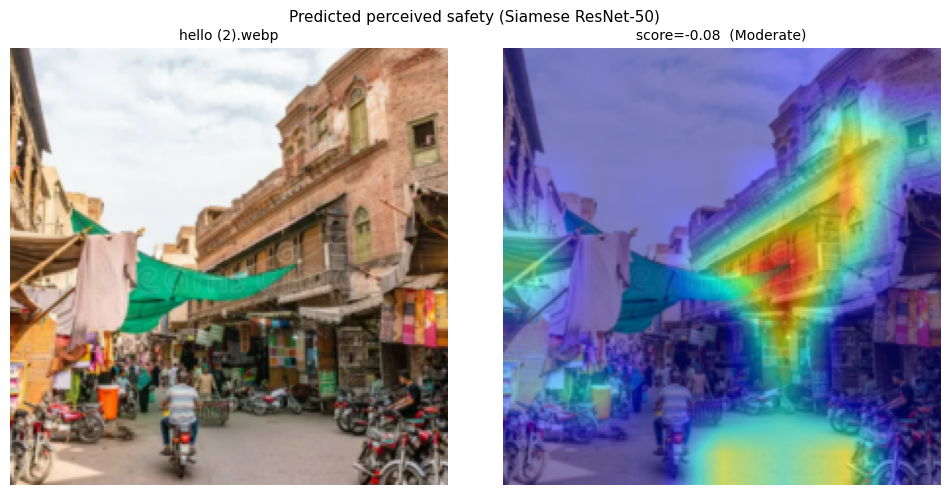

[('hello (2).webp', -0.08441162109375, 'Moderate')]

In [ ]:
"""
Inference demo — score any image and visualise Grad-CAM.

Paste as ONE cell after the post-training cell. The script defines four
callable functions that wrap your trained Siamese model:

  predict_safety(path)           -> single-image score + Grad-CAM panel
  predict_safety_batch(paths)    -> grid of images with scores + Grad-CAMs
  compare_pair(path_a, path_b)   -> Siamese pairwise comparison
  predict_uploaded()             -> Colab file-upload widget then predict

Each call returns the numeric score and a short verbal label, and renders
the visualisation inline (and optionally saves to Drive).
"""
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.amp import autocast
from PIL import Image
import matplotlib.pyplot as plt

try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    os.system("pip install -q grad-cam")
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image


# ============================================================
# Config
# ============================================================
CHECKPOINT_PATH = "/content/drive/MyDrive/place_pulse_safety/checkpoints/siamese_best.pt"
INFERENCE_OUT   = "/content/drive/MyDrive/place_pulse_safety/figures/inference"
os.makedirs(INFERENCE_OUT, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
EVAL_TFM = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(), transforms.Normalize(MEAN, STD),
])
RAW_TFM  = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224)])


# ============================================================
# Model + Grad-CAM (loaded once, cached at module level)
# ============================================================
class SiameseResNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.head = nn.Sequential(
            nn.Linear(2048, 256), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(256, 1),
        )
    def forward_once(self, x):
        x = self.backbone(x); x = x.view(x.size(0), -1)
        return self.head(x)


class _Wrap(nn.Module):
    """Wraps forward_once so GradCAM sees a [B, 1] output to grad on."""
    def __init__(self, m): super().__init__(); self.m = m
    def forward(self, x): return self.m.forward_once(x)


_model = None
_cam   = None

def _load_model():
    global _model, _cam
    if _model is not None:
        return _model, _cam
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    _model = SiameseResNet().to(device)
    _model.load_state_dict(ckpt["model_state_dict"])
    _model.eval()
    target_layer = _model.backbone[-2][-1]   # last block of ResNet layer4
    _cam = GradCAM(model=_Wrap(_model).to(device), target_layers=[target_layer])
    print(f"[model] loaded siamese_best.pt | epoch={ckpt['epoch']} | "
          f"val_pair_acc={ckpt['val_pair_acc']:.4f}")
    return _model, _cam


# ============================================================
# Helpers
# ============================================================
def _score_label(score: float) -> str:
    """Convert raw Siamese score (~[-3, +3]) to a verbal bucket."""
    if   score >=  1.5: return "Very safe"
    elif score >=  0.5: return "Safe"
    elif score >= -0.5: return "Moderate"
    elif score >= -1.5: return "Unsafe"
    else:                return "Very unsafe"


def _score_and_cam(image_path):
    """Return raw_image (HWC, 0-1 float), cam_overlay, scalar score, label."""
    model, cam = _load_model()
    img = Image.open(image_path).convert("RGB")
    raw = np.asarray(RAW_TFM(img)) / 255.0
    x   = EVAL_TFM(img).unsqueeze(0).to(device)
    with torch.no_grad(), autocast("cuda"):
        score = float(model.forward_once(x).item())
    cam_map = cam(input_tensor=x, targets=None)[0]
    overlay = show_cam_on_image(raw, cam_map, use_rgb=True)
    return raw, overlay, score, _score_label(score)


# ============================================================
# 1. Single-image scoring
# ============================================================
def predict_safety(image_path, show: bool = True, save_path: str | None = None):
    """
    Score one image and render a 2-panel figure (raw | Grad-CAM).
    Returns (score: float, label: str).
    """
    raw, overlay, score, label = _score_and_cam(image_path)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(raw);     axes[0].axis("off")
    axes[0].set_title(Path(image_path).name, fontsize=10)
    axes[1].imshow(overlay); axes[1].axis("off")
    axes[1].set_title(f"score={score:+.2f}  ({label})", fontsize=10)
    fig.suptitle("Predicted perceived safety (Siamese ResNet-50)", fontsize=11)
    fig.tight_layout()

    if save_path is None:
        save_path = os.path.join(INFERENCE_OUT, f"{Path(image_path).stem}_gradcam.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"  saved {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)
    return score, label


# ============================================================
# 2. Batch scoring — grid figure
# ============================================================
def predict_safety_batch(image_paths,
                         save_path: str | None = None,
                         ncols: int | None = None,
                         title: str = "Predicted perceived safety (Siamese ResNet-50)"):
    """
    Score multiple images and lay them out as a grid: row of raw images on top,
    row of Grad-CAM overlays underneath. Returns a list of (path, score, label).
    ncols defaults to min(n, 4) so small batches don't leave empty columns.
    """
    paths = [Path(p) for p in image_paths]
    n = len(paths)
    if ncols is None:
        ncols = min(max(n, 1), 4)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(2 * nrows, ncols,
                             figsize=(3.5 * ncols, 3.5 * 2 * nrows),
                             squeeze=False)

    results = []
    for i, p in enumerate(paths):
        raw, overlay, score, label = _score_and_cam(p)
        row = (i // ncols) * 2
        col = i % ncols
        axes[row, col].imshow(raw);     axes[row, col].axis("off")
        axes[row, col].set_title(f"{p.name}\nscore={score:+.2f}  ({label})", fontsize=9)
        axes[row + 1, col].imshow(overlay); axes[row + 1, col].axis("off")
        results.append((str(p), score, label))

    # Hide any unused cells (when n is not a multiple of ncols)
    for i in range(n, nrows * ncols):
        row = (i // ncols) * 2
        col = i % ncols
        axes[row, col].axis("off")
        axes[row + 1, col].axis("off")

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()

    if save_path is None:
        save_path = os.path.join(INFERENCE_OUT, "batch_gradcam.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"  saved {save_path}")
    plt.show()
    return results


# ============================================================
# 3. Pairwise comparison (the Siamese's natural query)
# ============================================================
def compare_pair(image_path_a, image_path_b):
    """
    Run the Siamese forward on a (A, B) pair the way it was trained.
    Returns dict with both scores, predicted winner, and P(A safer).
    """
    raw_a, ov_a, s_a, lbl_a = _score_and_cam(image_path_a)
    raw_b, ov_b, s_b, lbl_b = _score_and_cam(image_path_b)
    diff = s_a - s_b
    p_a  = 1.0 / (1.0 + np.exp(-diff))
    winner = "A" if diff > 0 else "B"

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(raw_a);  axes[0, 0].axis("off")
    axes[0, 0].set_title(f"A  ({Path(image_path_a).name})\nscore={s_a:+.2f}  ({lbl_a})", fontsize=10)
    axes[1, 0].imshow(ov_a);   axes[1, 0].axis("off")
    axes[0, 1].imshow(raw_b);  axes[0, 1].axis("off")
    axes[0, 1].set_title(f"B  ({Path(image_path_b).name})\nscore={s_b:+.2f}  ({lbl_b})", fontsize=10)
    axes[1, 1].imshow(ov_b);   axes[1, 1].axis("off")
    fig.suptitle(f"Predicted safer: image {winner}    "
                 f"P(A safer) = {p_a:.1%}", fontsize=12)
    fig.tight_layout()
    save_path = os.path.join(INFERENCE_OUT,
                             f"pair_{Path(image_path_a).stem}_vs_{Path(image_path_b).stem}.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"  saved {save_path}")
    plt.show()

    return {
        "score_a": s_a, "label_a": lbl_a,
        "score_b": s_b, "label_b": lbl_b,
        "score_diff": diff,
        "predicted_winner": winner,
        "p_a_safer": p_a,
    }


# ============================================================
# 4. Upload from local machine via Colab widget
# ============================================================
def predict_uploaded():
    """
    Opens the Colab file-upload widget. If you upload one image, you get a
    clean side-by-side panel (raw | Grad-CAM). If you upload several, you
    get a grid of scored images.
    """
    try:
        from google.colab import files
    except ImportError:
        raise RuntimeError("predict_uploaded() only works inside Colab. "
                           "Use predict_safety(path) for local files.")
    uploaded = files.upload()
    paths = list(uploaded.keys())
    if not paths:
        print("No files uploaded.")
        return []
    if len(paths) == 1:
        score, label = predict_safety(paths[0])
        return [(paths[0], score, label)]
    return predict_safety_batch(paths)


# ============================================================
# Pre-load the model so the first call is instant
# ============================================================
_load_model()
predict_uploaded()


In [ ]:
import pandas as pd
import kagglehub
from pathlib import Path

DATA_DIR = kagglehub.dataset_download("shubham6147/mit-place-pulse")
votes = pd.read_csv(Path(DATA_DIR) / "votes_clean.csv")

print("Columns:", list(votes.columns))   # confirm the exact column names first

# Auto-detect the city columns (adjust if names differ)
def pick(cols, options):
    return next((c for c in options if c in cols), None)

lc = pick(votes.columns, ["left_city", "leftCity", "left_place_name", "place_name_left"])
rc = pick(votes.columns, ["right_city", "rightCity", "right_place_name", "place_name_right"])

# Also try country, in case city isn't present
lco = pick(votes.columns, ["left_country", "leftCountry"])
rco = pick(votes.columns, ["right_country", "rightCountry"])

if lc and rc:
    cities = pd.concat([votes[lc], votes[rc]]).dropna().str.strip()
    counts = cities.value_counts()
    print(f"\n{counts.shape[0]} unique cities:\n")
    print(counts.to_string())
elif lco and rco:
    countries = pd.concat([votes[lco], votes[rco]]).dropna().str.strip()
    print(f"\n{countries.nunique()} unique countries:\n")
    print(countries.value_counts().to_string())
else:
    print("No city/country column found. Print the columns above and tell me the names.")

100%|██████████| 2.48G/2.48G [00:36<00:00, 73.4MB/s]

Extracting files...


Columns: ['Unnamed: 0', 'place_id_left', 'place_id_right', 'study_id', 'left', 'right', 'voter_uniqueid', 'choice', 'study_question', 'place_name_right', 'place_name_left', 'day', 'time', 'long_right', 'lat_right', 'long_left', 'lat_left']

56 unique cities:

Atlanta           114132
Berlin            110848
Tokyo             107331
Rio De Janeiro    105310
Santiago           96671
New York           96373
Sydney             94248
Toronto            93172
Chicago            91270
Houston            86278
Sao Paulo          84568
Warsaw             84143
Moscow             80981
Philadelphia       78721
Melbourne          76413
London             76171
Singapore          74094
Montreal           73478
Cape Town          70920
Paris              70858
Denver             67288
Munich             62967
Rome               60958
Madrid             60725
Bucharest          59953
Mexico City        58709
Belo Horizonte     55539
Portland           53611
Lisbon             52924
Johannesburg   